In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

In [15]:
def simulate_location_dpp(coords: np.ndarray, n_select: int=15, length_scale: float=0.2) -> (list, np.ndarray):
    # 1. 各地点の「需要/クオリティ」を定義 (例: 中心部ほど高い)
    # q_i = exp(-||x_i - center||^2)
    center = np.array([0.5, 0.5])
    quality = np.exp(-np.sum((coords - center)**2, axis=1) / 0.5)
    
    # 2. 類似度行列 S の計算 (RBFカーネル)""
    # 距離が近いほど S_ij が大きく（似ていると判定され）、行列式が小さくなるため選ばれにくくなる
    dist_matrix = squareform(pdist(coords, 'euclidean'))
    S = np.exp(-(dist_matrix**2) / (2 * length_scale**2))
    
    # 3. L-ensemble 行列の構築: L = diag(q) * S * diag(q)
    L = np.outer(quality, quality) * S
    
    # 4. 貪欲法によるMAP推定（実用的なサブセット選択）
    # 行列式を最大化する点を1つずつ選ぶ
    selected = []
    candidates = list(range(len(coords)))
    
    for _ in range(n_select):
        best_det = -1
        best_idx = -1
        for c in candidates:
            current_set = selected + [c]
            # 部分行列の行列式を計算
            sub_L = L[np.ix_(current_set, current_set)]
            det = np.linalg.det(sub_L)
            if det > best_det:
                best_det = det
                best_idx = c
        selected.append(best_idx)
        candidates.remove(best_idx)
        
    return selected, quality

In [16]:
def plot_results(coords: np.ndarray, selected: list, quality: np.ndarray) -> None:
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], c=quality, cmap='YlOrRd', alpha=0.3, label='Potential Sites (Color=Demand)')
    plt.scatter(coords[selected, 0], coords[selected, 1], c='blue', s=100, edgecolors='white', label='Selected Stores (DPP)')
    plt.title("Store Location Optimization using DPP (Repulsion + Quality)")
    plt.colorbar(label='Demand Intensity')
    plt.legend()
    plt.show()

In [17]:
# 候補地の生成（例：都市内のランダムな候補地）
n_candidates = 200
coords = np.random.rand(n_candidates, 2)

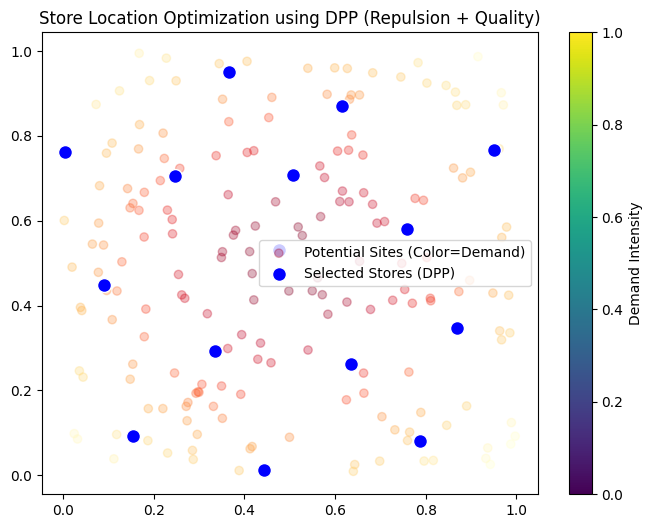

In [18]:
# 実行と可視化
selected, quality = simulate_location_dpp(coords)
plot_results(coords, selected, quality)

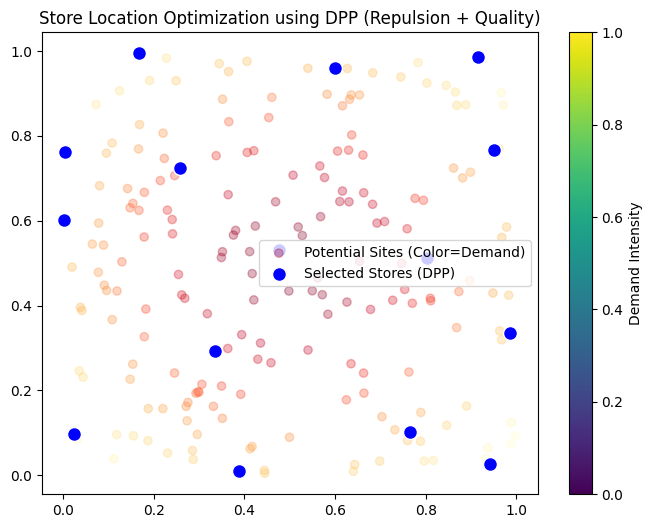

In [19]:
# 実行と可視化
selected, quality = simulate_location_dpp(coords, length_scale=2.0)
plot_results(coords, selected, quality)

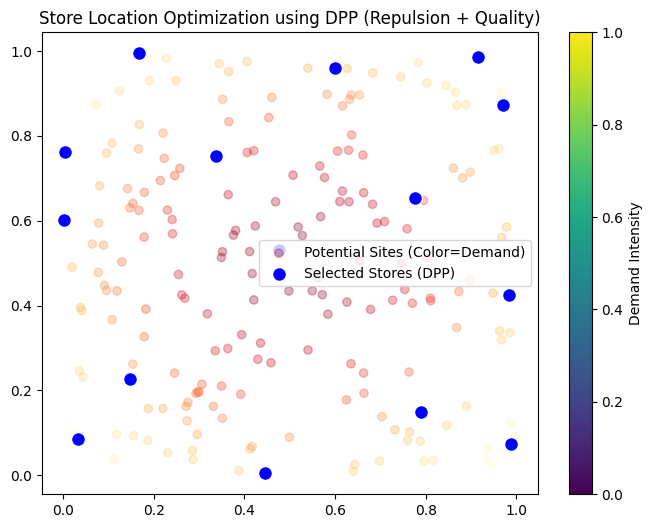

In [20]:
# 実行と可視化
selected, quality = simulate_location_dpp(coords, n_select=15, length_scale=1.0)
plot_results(coords, selected, quality)